In [2]:
import fast_rv as frv
import numpy as np
import matplotlib.cm
import matplotlib.pyplot as plt
cmap = matplotlib.cm.get_cmap("Spectral")
#%matplotlib widget
#matplotlib.use("TkAgg")
from matplotlib.widgets import RangeSlider
from PyAstronomy.modelSuite import KeplerRVModel
from astroquery.vizier import Vizier
from astropy.timeseries import LombScargle

/tmp/ipykernel_7247/3176628646.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Spectral")


In [3]:
catalog_id = "J/A+A/414/351"
t = frv.vizier_table_inspection(catalog_id)


Table description: Radial velocity measurements for HD 9826
Total data points: 71
Time : Barycentric Julian date
RV   : Barycentric radial velocity (1)
Err  : Full RV uncertainty
authors:                                  authors                                  
--------------------------------------------------------------------------
Naef D.; Mayor M.; Beuzit J.L.; Perrier C.; Queloz D.; Sivan J.P.; Udry S.


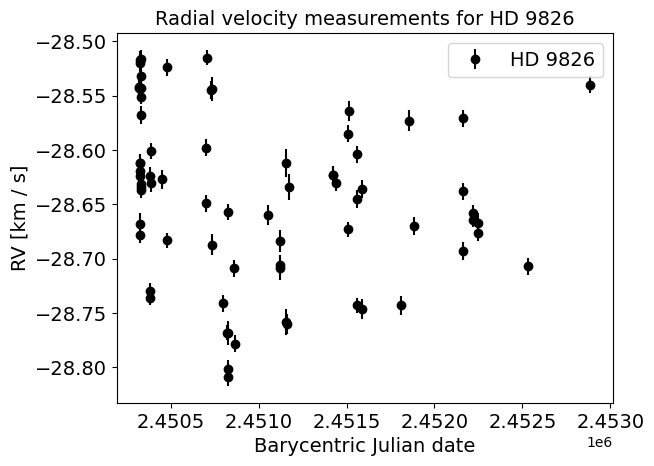

In [4]:
name = "HD 9826" 
time_data, rv_data_ms , err_rv_ms = frv.get_vizier_data(catalog_id,name)
plt.show()
                        

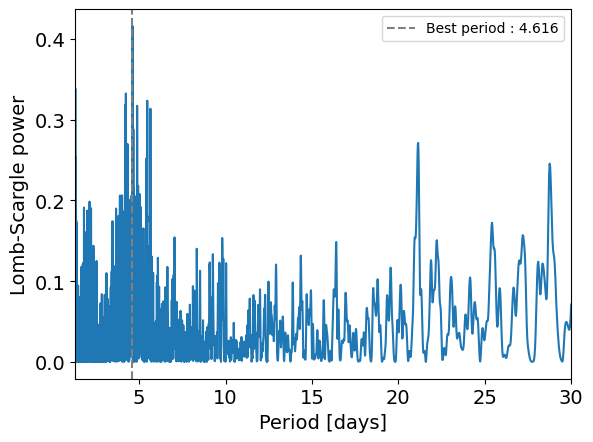

np.float64(4.61578250292051)

In [5]:
#a good guess ! (see ARCHIVE )
period_guess = frv.run_periodogram( time_data , rv_data_ms , err_rv_ms , 1.3, 30)
plt.show()
period_guess


In [9]:
#from NASA exop;anet archive 
params = {
    "mstar": 0.191,
    "per": period_guess,
    "e": 0.02150,
    "w": 242,
    "K": 77.2
}
x_data, y_data, y_err, xgrid, ygrid, model = frv.fitting_rv_model(time_data, rv_data_ms, 
                                                              err_rv_ms, **params)
                        

Optimization terminated successfully.
         Current function value: 3672.698452
         Iterations: 253
         Function evaluations: 509


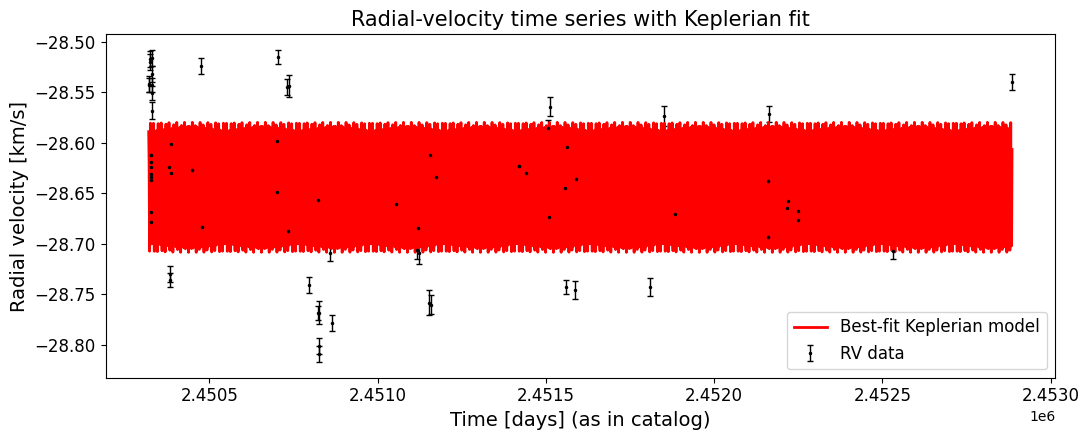

In [10]:
plt.figure(figsize=(11, 4.5))

# data
plt.errorbar(
    x_data, y_data/1e3, yerr=y_err/1e3,
    fmt="k.", ms=3, capsize=2, elinewidth=1,
    label="RV data"
)
# model
plt.plot(xgrid, ygrid/1e3, "r-", lw=2, label="Best-fit Keplerian model")

plt.title("Radial-velocity time series with Keplerian fit", fontsize=15)
plt.xlabel("Time [days] (as in catalog)", fontsize=14)
plt.ylabel("Radial velocity [km/s]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

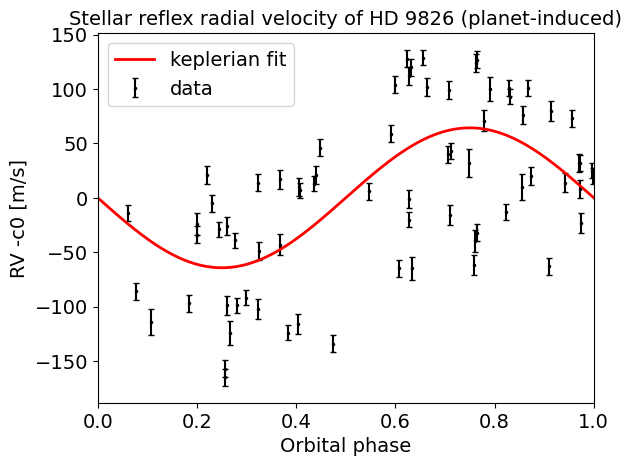

In [11]:
#finally - phase fold it
phase = ((x_data - model["tau1"]) / model["per1"]) % 1.0
idx_p = np.argsort(phase)

phase_grid = np.linspace(0, 1, 2000)
x_phase = model["tau1"] + phase_grid * model["per1"]
y_phase = model.evaluate(x_phase)


plt.errorbar(phase[idx_p], (y_data - model["c0"])[idx_p], yerr=y_err[idx_p],
             fmt="k.", ms=3, capsize=2, label="data")
plt.plot(phase_grid, y_phase - model["c0"], "r-", lw=2, label="keplerian fit")
plt.xlim(0, 1)
plt.xlabel("Orbital phase", fontsize = 14)
plt.ylabel("RV -c0 [m/s]" , fontsize = 14)
plt.title(f"Stellar reflex radial velocity of {name} (planet-induced)",fontsize = 14)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14)
plt.legend( fontsize = 14)
plt.show()